In [1]:
import os
import cv2
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (EarlyStopping,ReduceLROnPlateau,ModelCheckpoint)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import (confusion_matrix,classification_report,ConfusionMatrixDisplay)
warnings.filterwarnings("ignore")

2026-07-24 02:09:19.370693: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
dataset_path = r"/Users/Aashi_Dixit/Desktop/DS_SUMMER_TRAINING/MAIN PROJECT/CNN_dataset/Air Pollution Image Dataset/Combined_Dataset/IND_and_NEP"

In [4]:
print(os.listdir(dataset_path))

['b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'a_Good', 'f_Severe', 'e_Very_Unhealthy']


In [5]:
for folder in os.listdir(dataset_path):
    path = os.path.join(dataset_path, folder)
    print(folder, ":", len(os.listdir(path)))

b_Moderate : 1573
c_Unhealthy_for_Sensitive_Groups : 2863
d_Unhealthy : 2622
a_Good : 1541
f_Severe : 1447
e_Very_Unhealthy : 2194


In [6]:
IMG_SIZE = (160,160)
BATCH_SIZE = 64
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [7]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 12240 files belonging to 6 classes.
Using 9792 files for training.


In [8]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 12240 files belonging to 6 classes.
Using 2448 files for validation.


In [9]:
class_names = train_ds.class_names

print(class_names)

with open("class_names.pkl","wb") as f:
    pickle.dump(class_names,f)

['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']


2026-07-24 02:16:55.739811: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


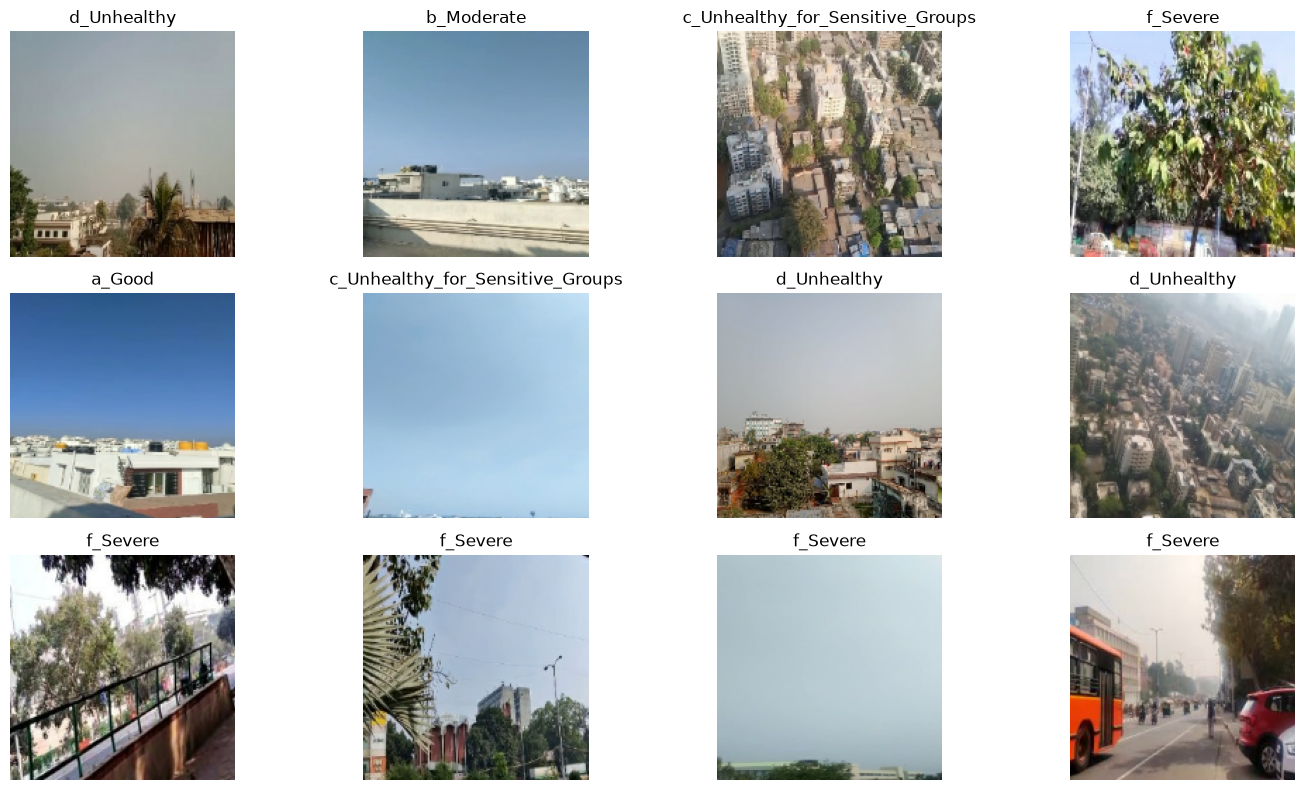

In [10]:
plt.figure(figsize=(15,8))

for images, labels in train_ds.take(1):

    for i in range(12):

        ax = plt.subplot(3,4,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
train_ds = train_ds.map(
    lambda x,y:(preprocess_input(x),y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x,y:(preprocess_input(x),y),
    num_parallel_calls=AUTOTUNE
)

In [12]:
train_ds = (
    train_ds
    .cache()
    .shuffle(2000)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .cache()
    .prefetch(AUTOTUNE)
)


In [13]:
data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.15),

    layers.RandomZoom(0.15),

    layers.RandomContrast(0.15)

])

In [14]:
for image_batch, label_batch in train_ds.take(1):

    sample_image = image_batch[0]

plt.figure(figsize=(8,8))

2026-07-24 02:17:56.389503: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:19: Filling up shuffle buffer (this may take a while): 82 of 2000
2026-07-24 02:18:03.953605: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2026-07-24 02:18:03.980268: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<Figure size 800x800 with 0 Axes>

<Figure size 800x800 with 0 Axes>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.5..128.0].
Clipping input data to the valid range for imshow with RGB dat

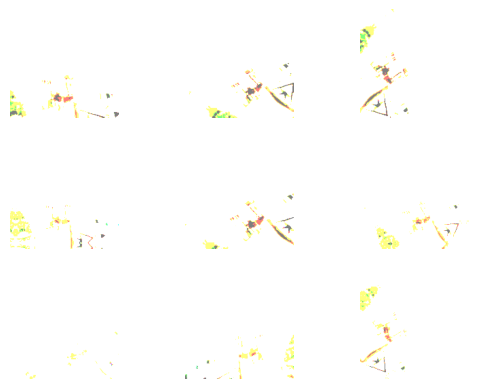

In [15]:
for i in range(9):

    ax = plt.subplot(3,3,i+1)

    aug = data_augmentation(tf.expand_dims(sample_image,0))

    plt.imshow(((aug[0]+1)/2))

    plt.axis("off")

plt.show()


In [16]:
base_model = EfficientNetB0(

    weights="imagenet",

    include_top=False,

    input_shape=(160,160,3)

)

In [17]:
base_model.trainable = False

inputs = keras.Input(shape=(160,160,3))

In [18]:
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)

In [19]:
outputs = layers.Dense(
    len(class_names),
    activation="softmax")(x)
model = keras.Model(inputs, outputs)

In [20]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [21]:
callbacks = [EarlyStopping(monitor="val_loss",patience=2,restore_best_weights=True),ReduceLROnPlateau(monitor="val_loss",factor=0.3,patience=1,

        verbose=1),ModelCheckpoint("best_cnn.keras",monitor="val_accuracy",save_best_only=True,verbose=1)]


In [22]:
history = model.fit(train_ds,validation_data=val_ds,epochs=5,callbacks=callbacks)

Epoch 1/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4827 - loss: 1.3133  
Epoch 1: val_accuracy improved from None to 0.60008, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
153/153 ━━━━━━━━━━━━━━━━━━━━ 505s 3s/step - accuracy: 0.4827 - loss: 1.3133 - val_accuracy: 0.6001 - val_loss: 1.0652 - learning_rate: 0.0010
Epoch 2/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6109 - loss: 1.0168  
Epoch 2: val_accuracy improved from 0.60008 to 0.64502, saving model to best_cnn.keras

Epoch 2: finished saving model to best_cnn.keras
153/153 ━━━━━━━━━━━━━━━━━━━━ 421s 3s/step - accuracy: 0.6109 - loss: 1.0168 - val_accuracy: 0.6450 - val_loss: 0.9426 - learning_rate: 0.0010
Epoch 3/5
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6548 - loss: 0.9082  
Epoch 3: val_accuracy improved from 0.64502 to 0.68382, saving model to best_cnn.keras

Epoch 3: finished saving model to best_cnn.keras
153/153 ━━━━━━━━━━━━━━━━━━━━ 447s 3s/step - accura

In [23]:
val_acc = max(history.history["val_accuracy"])
print(f"Best Validation Accuracy: {val_acc:.4f}")
if val_acc < 0.90:
    print("Validation accuracy below 90%. Starting Fine Tuning...\n")
    base_model.trainable = True
    for layer in base_model.layers[:-10]:
        layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(1e-5),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])

    history_fine = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=2,
        callbacks=callbacks)
else:
    print("Validation accuracy is already good.")
    print("Skipping Fine Tuning.")

Best Validation Accuracy: 0.7234
Validation accuracy below 90%. Starting Fine Tuning...

Epoch 1/2
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6706 - loss: 0.8903  
Epoch 1: val_accuracy did not improve from 0.72345
153/153 ━━━━━━━━━━━━━━━━━━━━ 607s 4s/step - accuracy: 0.6706 - loss: 0.8903 - val_accuracy: 0.7194 - val_loss: 0.7418 - learning_rate: 1.0000e-05
Epoch 2/2
153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7016 - loss: 0.7984  
Epoch 2: val_accuracy did not improve from 0.72345
153/153 ━━━━━━━━━━━━━━━━━━━━ 479s 3s/step - accuracy: 0.7016 - loss: 0.7984 - val_accuracy: 0.7234 - val_loss: 0.7265 - learning_rate: 1.0000e-05


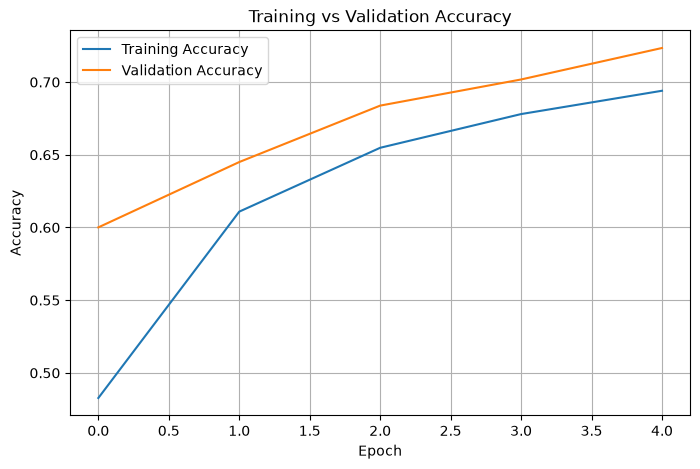

In [24]:
# ==========================
# 13. ACCURACY GRAPH
# ==========================

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid()

plt.show()

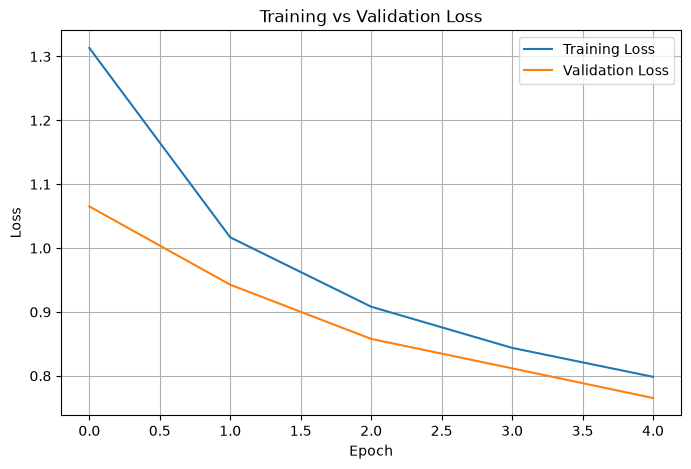

In [25]:
# ==========================
# 14. LOSS GRAPH
# ==========================

plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid()

plt.show()

In [26]:
# ==========================
# 15. MODEL EVALUATION
# ==========================

loss, accuracy = model.evaluate(val_ds)

print(f"\nValidation Accuracy : {accuracy:.4f}")

print(f"Validation Loss : {loss:.4f}")

39/39 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.7234 - loss: 0.7265 

Validation Accuracy : 0.7234
Validation Loss : 0.7265


In [27]:
# ==========================
# 16. PREDICTIONS
# ==========================

y_true = []

y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)

y_pred = np.array(y_pred)

2026-07-24 03:26:04.781329: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<Figure size 800x600 with 0 Axes>

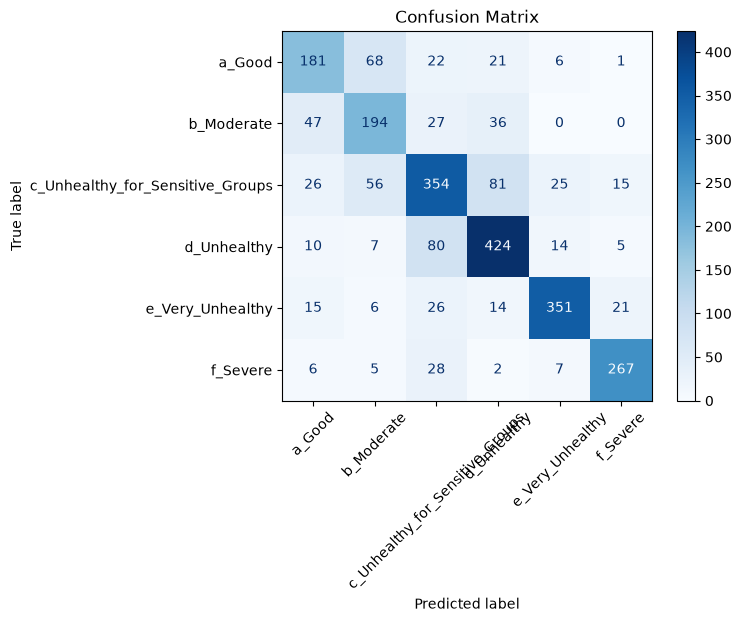

In [28]:
# ==========================
# 17. CONFUSION MATRIX
# ==========================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")

plt.show()

In [29]:
# ==========================
# 18. CLASSIFICATION REPORT
# ==========================

print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )

)

                                  precision    recall  f1-score   support

                          a_Good       0.64      0.61      0.62       299
                      b_Moderate       0.58      0.64      0.61       304
c_Unhealthy_for_Sensitive_Groups       0.66      0.64      0.65       557
                     d_Unhealthy       0.73      0.79      0.76       540
                e_Very_Unhealthy       0.87      0.81      0.84       433
                        f_Severe       0.86      0.85      0.86       315

                        accuracy                           0.72      2448
                       macro avg       0.72      0.72      0.72      2448
                    weighted avg       0.73      0.72      0.72      2448



In [30]:
# ==========================
# 19. SAVE MODEL
# ==========================

best_model = keras.models.load_model("best_cnn.keras")

best_model.save("cnn_model.keras")

print("CNN Model Saved Successfully")

CNN Model Saved Successfully


In [31]:
# ==========================
# 20. IMAGE PREDICTION FUNCTION
# ==========================

from tensorflow.keras.preprocessing import image

def predict_image(img_path):

    img = image.load_img(

        img_path,

        target_size=(160,160)

    )

    img = image.img_to_array(img)

    img = preprocess_input(img)

    img = np.expand_dims(img, axis=0)

    prediction = best_model.predict(img, verbose=0)

    idx = np.argmax(prediction)

    confidence = np.max(prediction)

    print(f"\nPredicted Class : {class_names[idx]}")

    print(f"Confidence : {confidence*100:.2f}%")

In [39]:
predict_image(r"CNN_dataset/Air Pollution Image Dataset/Combined_Dataset/IND_and_NEP/a_Good/BENGR_Good_2023-02-19-08.30-1-16.jpg")
#predict_image("sample.jpg")


Predicted Class : c_Unhealthy_for_Sensitive_Groups
Confidence : 49.38%


In [40]:
# ==========================
# 21. AQI SUMMARY
# ==========================

aqi_path = r"/Users/Aashi_Dixit/Desktop/DS_SUMMER_TRAINING/MAIN PROJECT/CNN_dataset/Air Pollution Image Dataset/Combined_Dataset/IND_and_Nep_AQI_Dataset.csv"

aqi_df = pd.read_csv(aqi_path)

summary = (

    aqi_df

    .groupby("AQI_Class")[

        ["AQI","PM2.5","PM10","CO","SO2","NO2","O3"]

    ]

    .mean()

    .round(2)

)

summary.to_csv("aqi_summary.csv")

summary

,AQI,PM2.5,PM10,CO,SO2,NO2,O3
AQI_Class,,,,,,,
a_Good,39.12,20.59,35.71,223.89,15.77,11.33,22.41
b_Moderate,74.03,32.09,57.44,148.65,7.89,12.20,27.95
c_Unhealthy_for_Sensitive_Groups,123.51,90.37,115.53,102.71,10.26,32.34,39.14
d_Unhealthy,162.55,119.69,152.49,40.27,8.75,27.04,54.40
e_Very_Unhealthy,251.91,268.50,247.49,69.01,17.88,71.76,49.16
f_Severe,374.91,350.01,251.53,63.35,20.97,74.76,30.41


In [41]:
# ==========================
# 22. HEALTH ADVICE
# ==========================

health_info = {

"a_Good":
"Air quality is good. Safe for outdoor activities.",

"b_Moderate":
"Acceptable. Sensitive people should reduce prolonged exposure.",

"c_Unhealthy_for_Sensitive_Groups":
"Children and elderly should reduce outdoor activities.",

"d_Unhealthy":
"Reduce prolonged outdoor exposure.",

"e_Very_Unhealthy":
"Wear an N95 mask. Stay indoors if possible.",

"f_Severe":
"Avoid going outdoors. Health emergency conditions."

}

In [42]:
# ==========================
# 23. POLLUTION SOURCE
# ==========================

pollution_source = {

"a_Good":
"Minimal pollution",

"b_Moderate":
"Light vehicle emissions",

"c_Unhealthy_for_Sensitive_Groups":
"Traffic and road dust",

"d_Unhealthy":
"Traffic + industrial emissions",

"e_Very_Unhealthy":
"Construction + factories",

"f_Severe":
"Industrial smoke, biomass burning, fire"

}

In [43]:
# ==========================
# 24. TRAVEL ADVICE
# ==========================

travel = {

"a_Good":
"Excellent for outdoor exercise.",

"b_Moderate":
"Suitable for walking and cycling.",

"c_Unhealthy_for_Sensitive_Groups":
"Sensitive people should avoid prolonged exercise.",

"d_Unhealthy":
"Outdoor exercise not recommended.",

"e_Very_Unhealthy":
"Stay indoors if possible.",

"f_Severe":
"Avoid all outdoor activities."

}

In [50]:
# ==========================
# 25. COMPLETE TEST
# ==========================

predict_image(r"CNN_dataset/Air Pollution Image Dataset/Combined_Dataset/IND_and_NEP/a_Good/BENGR_Good_2023-02-19-08.30-1-16.jpg")
label = class_names[np.argmax(best_model.predict(predict_image, verbose=0))]

print("\nHealth Advice :")

print(health_info[label])

print("\nPossible Pollution Source :")

print(pollution_source[label])

print("\nOutdoor Recommendation :")

print(travel[label])

Predicted Class : c_Unhealthy_for_Sensitive_Groups
Confidence : 49.38%


ValueError: Unrecognized data type: x=<function predict_image at 0x14c3ee8e0> (of type <class 'function'>)

In [46]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(160,160))
    img = image.img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    prediction = best_model.predict(img, verbose=0)

    idx = np.argmax(prediction)
    confidence = np.max(prediction)

    label = class_names[idx]

    print(f"Predicted Class : {label}")
    print(f"Confidence : {confidence*100:.2f}%")

    return label, confidence

In [49]:
label, confidence = predict_image(r"CNN_dataset/Air Pollution Image Dataset/Combined_Dataset/IND_and_NEP/a_Good/BENGR_Good_2023-02-19-08.30-1-16.jpg")
print("\nHealth Advice:")
print(health_info[label])

print("\nPossible Pollution Source:")
print(pollution_source[label])

print("\nOutdoor Recommendation:")
print(travel[label])

Predicted Class : c_Unhealthy_for_Sensitive_Groups
Confidence : 49.38%

Health Advice:
Children and elderly should reduce outdoor activities.

Possible Pollution Source:
Traffic and road dust

Outdoor Recommendation:
Sensitive people should avoid prolonged exercise.
